# STAT 207 Project 03 - Video Game Sales & Commercial Success Analysis

Nao Wainer

<hr>

## 1. Introduction

## Predicting Video Game Sales and Understand the Relationship Between Variables

This analysis draws on a dataset of over one thousand video games released between 2004 and 2010, originally compiled and curated by Dr. Joe Cox. The dataset includes each game's US sales figures, platform, genre, critic review scores, and crowd-sourced playtime estimates collected from "How Long to Beat" which is a community site where players log how long it takes them to complete a game. Our first reserach question for linear regression is "What is the relationship between a game's critic review score and its US sales figures, after controlling for whether the game is a sequel, its used price, the platform it was released on, and how long the game has been on the market both in the sample and in the underlying population? How well does this model perform when predicting sales for new, unseen games?" Our second research question for logistic regression is "How do a game's critic review score, sequel status, and online multiplayer availability relate to the log-odds of a game being a blockbuster (selling over 1 million copies) in the sample training data? How does a classifier built on this model perform on new data?" The response variable for the first research question is a game's US sales figures, measured in millions of units sold. This is a continuous quantitative variable, making it well-suited for a linear regression model. The response variable for the second research question is whether a game is a blockbuster, defined as selling over 1 million copies. This is a logical variable already present in the dataset, where a value of 1 indicates the game surpassed that sales threshold and 0 indicates it did not. This variable serves as the outcome for our logistic regression classifier. Understanding what drives video game sales is valuable to publishers, retailers, and investors. A publisher could use the linear regression model to estimate how decisions like adding online multiplayer or targeting higher critic scores might impact a game's sales, helping them allocate development budgets more effectively. The blockbuster classifier has equally practical uses, a retailer deciding how many units to stock, or an investor evaluating a studio's upcoming releases, could use it to gauge a game's commercial potential before any sales data is available.

In [18]:
#Imports here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf

In [19]:
df = pd.read_csv("video_games copy.csv", encoding = "unicode-escape")
df

,Console,Title,US Sales (millions),Block4,Block2,Block1,Block0.5,YearReleased,2004,2005,...,Tricks,Volleyball,Wakeboarding,Wrestling,FirstPerson,Platform,Isometric,SideScrolling,TopDown,ThirdPerson
0,Nintendo DS,Super Mario 64 DS,4.69,1,1,1,1,2004,1,0,...,0,0,0,0,0,1,0,0,0,1
1,Sony PSP,Lumines: Puzzle Fusion,0.56,0,0,0,1,2004,1,0,...,0,0,0,0,0,0,0,0,0,0
2,Nintendo DS,WarioWare Touched!,0.54,0,0,0,1,2004,1,0,...,0,0,0,0,0,1,1,1,1,1
3,Sony PSP,Hot Shots Golf: Open Tee,0.49,0,0,0,0,2004,1,0,...,0,0,0,0,0,0,0,0,0,1
4,Nintendo DS,Spider-Man 2,0.45,0,0,0,0,2004,1,0,...,0,0,0,0,0,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1765,PlayStation 3,MotoGP 09/10,0.04,0,0,0,0,2010,0,0,...,0,0,0,0,1,0,0,0,0,1
1766,PlayStation 3,Prison Break: The Conspiracy,0.04,0,0,0,0,2010,0,0,...,0,0,0,0,0,0,0,0,0,1
1767,Nintendo Wii,"Sakura Wars: So Long, My Love",0.04,0,0,0,0,2010,0,0,...,0,0,0,0,0,0,0,0,0,1
1768,X360,Record of Agarest War (The Really Naughty Limi...,0.04,0,0,0,0,2010,0,0,...,0,0,0,0,0,0,1,0,0,0


In [14]:
list(df.columns)

['Console',
 'Title',
 'US Sales (millions)',
 'Block4',
 'Block2',
 'Block1',
 'Block0.5',
 'YearReleased',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 'YearReleasedSq',
 'Publisher',
 'Genre',
 'Sequel',
 'Re-release',
 'Usedprice',
 'lnUsedPrice',
 'Review Score',
 'ReviewSq',
 'RatingE',
 'RatingT',
 'RatingM',
 'Lifecycle',
 'LifecycleSq',
 'MaxPlayers',
 'MaxPlayersSq',
 'Online',
 'Licensed',
 'Handheld',
 'Accessory',
 'LtdEdition',
 'Multiplatform',
 'GBA',
 'GCN',
 'NDS',
 'Wii',
 'PS2',
 'PS3',
 'PSP',
 'Xbox',
 'X360',
 'Action',
 'Adventure',
 'Educational',
 'Racing',
 'RPG',
 'Simulation',
 'Sports',
 'Strategy',
 '2K',
 'Acclaim',
 'Activision',
 'Atari',
 'Capcom',
 'Disney',
 'Eidos',
 'EA',
 'Infograme',
 'Konami',
 'Microsoft',
 'Midway',
 'Namco',
 'Nintendo',
 'Rockstar',
 'Sony',
 'Sega',
 'THQ',
 'SquareEnix',
 'Ubisoft',
 'Adult',
 'Anime',
 'Arcade',
 'Battlemech',
 'Boardgame',
 'Cards',
 'Casino',
 'Chess',
 'Comics',
 'Cyberpunk',
 'Dete

## 2. Linear Regression Analytical Tasks

Research Question: "What is the relationship between a game's critic review score and its US sales figures, after controlling for whether the game is a sequel, its used price, the platform it was released on, and how long the game has been on the market both in the sample and in the underlying population? How well does this model perform when predicting sales for new, unseen games?"

In [47]:
df_train, df_test = train_test_split(df, test_size = 0.3, random_state = 670)

In [48]:
df.columns = df.columns.str.strip()          # remove hidden spaces
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("(", "")
df.columns = df.columns.str.replace(")", "")

print(df.columns)

Index(['Console', 'Title', 'US_Sales', 'Block4', 'Block2', 'Block1',
       'Block0.5', 'YearReleased', '2004', '2005',
       ...
       'Tricks', 'Volleyball', 'Wakeboarding', 'Wrestling', 'FirstPerson',
       'Platform', 'Isometric', 'SideScrolling', 'TopDown', 'ThirdPerson'],
      dtype='str', length=166)


In [43]:
results = smf.ols("US_Sales ~ Review_Score + Sequel + Usedprice + Platform", data = df).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               US_Sales   R-squared:                       0.117
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                     58.33
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           2.71e-46
Time:                        15:51:36   Log-Likelihood:                -2512.5
No. Observations:                1770   AIC:                             5035.
Df Residuals:                    1765   BIC:                             5062.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -1.2973      0.123    -10.508      0.000      -1.539      -1.055
Review_Score     0.0193      0.002     10.543      0.000       0.016       0.023
Sequel           0.1238      0.049      2.542      0.011       0.028       0.219
Usedprice        0.0191      0.003      6.103      0.000       0.013       0.025
Platform         0.1811      0.085      2.136      0.033       0.015       0.347
==============================================================================
Omnibus:                     2342.610   Durbin-Watson:                   0.654
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           424915.778
Skew:                           7.311   Prob(JB):                         0.00
Kurtosis:                      77.483   Cond. No.                         376.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### linear regression equation for our model

Y-hat = -1.2973	+ 0.0193 * Review_Score + 0.1238 * Sequel + 0.0191 * Usedprice + 0.1811 * Platform

Slope coefficient interpretation: 

The slope coefficient for Review Score is 0.0193, meaning that for each one-point increase in a game's critic review score, US sales are expected to increase by approximately 0.019 million units (about 19,000 copies), after controlling for sequel status, used price, and platform. This indicates a positive relationship between critic review scores and sales in our sample — games that receive higher reviews tend to sell more copies.


95% confidence interval for the slope coefficient:

The 95% confidence interval for the slope coefficient of Review Score is (0.016, 0.023). This means we are 95% confident that in the underlying population, each one-point increase in a game's critic review score is associated with an increase in US sales of between 0.016 and 0.023 million units (roughly 16,000 to 23,000 copies), after controlling for sequel status, used price, and platform.
Since this interval does not contain zero, we have sufficient evidence to conclude that there is a statistically significant positive relationship between critic review score and US sales in the underlying population, not just in our sample. This suggests that review scores are a meaningful predictor of a game's commercial performance more broadly.

In [44]:
fitted = results.fittedvalues
residuals = results.resid

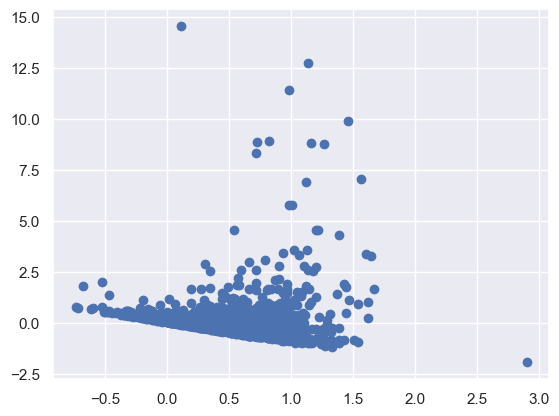

In [45]:
plt.scatter(fitted, residuals)

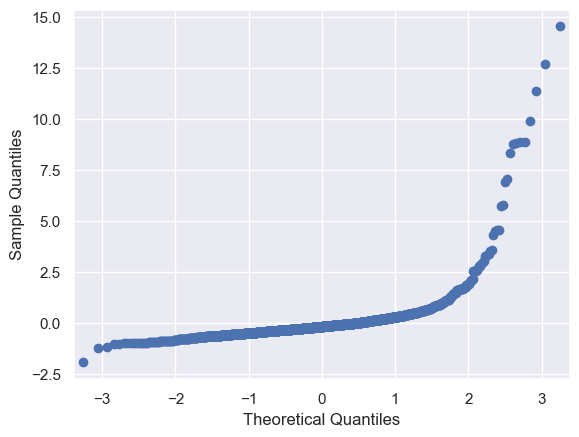

In [41]:
import statsmodels.api as sm 
sm.qqplot(results.resid)
plt.show()


Residuals vs. Fitted Plot: The residuals vs. fitted plot reveals two clear violations. First, the spread of residuals increases as fitted values increase, indicating that the equal variance (homoscedasticity) condition is not met. Second, several extreme outliers are visible in the upper portion of the plot, suggesting a small number of games with unusually high sales are pulling the model's predictions. A random, even scatter around zero would be ideal — this plot does not show that.

Q-Q Plot: The Q-Q plot shows that the residuals deviate sharply from the diagonal line in the upper tail, confirming that the normality condition is not met. The residuals are heavily right-skewed, which is consistent with the skewness value of 7.311 from the regression output.


Overall: These diagnostic plots suggest that the linear regression conditions of equal variance and normality are not fully satisfied, largely driven by a small number of blockbuster games with exceptionally high sales. However, with 1,770 observations, the Central Limit Theorem offers some protection, meaning our slope estimate and confidence interval for Review Score are still reasonable approximations — but should be interpreted with caution given these violations.

#### E: Evaluate Your Model Preformance

The R-squared value for this model is 0.117, meaning that approximately 11.7% of the variability in US game sales is explained by critic review score, sequel status, used price, and platform in the training data. This is quite low, suggesting that the majority of variability in sales is driven by factors not captured in this model. This is not entirely surprising in the context of video game sales, as commercial success can be heavily influenced by hard-to-quantify factors such as marketing spend, cultural trends, franchise loyalty, and timing of release — none of which are present in this dataset.


In [52]:
from sklearn.metrics import root_mean_squared_error
y_train_true = df_train["US_Sales"]
y_train_pred = results.predict(df_train)
y_test_true = df_test["US_Sales"]
y_test_pred = results.predict(df_test)

In [53]:
rmse_test = root_mean_squared_error(y_test_true, y_test_pred)
rmse_test

0.9865306046845422

In [54]:
rmse_train = root_mean_squared_error(y_train_true, y_train_pred)
rmse_train

1.0064780362854822

RMSE Interpretation: 

The RMSE on the training data is 1.006 and the RMSE on the test data is 0.987, meaning that on average the model's predictions are off by approximately 1 million units in both cases. Given that most games in this dataset sell well under 1 million copies, this is quite high and suggests the model struggles to predict sales precisely. However, the fact that the test RMSE is slightly lower than the training RMSE is a good sign, it indicates the model is not overfitting and generalizes reasonably well to new, unseen data. The similar values between training and test RMSE suggest the model is stable, even if its overall predictive accuracy is limited.

## 3. Logistic Regression Analytical Tasks

Logistic Regression Research Question: "How do a game's critic review score, sequel status, and online multiplayer availability relate to the log-odds of a game being a blockbuster (selling over 1 million copies) in the sample training data? How does a classifier built on this model perform on new data?"

#### Fit a logistic regression model to the same training data from the Linear Regression Task

In [57]:
results2 = smf.logit("Block1 ~ Review_Score + Sequel + Online", data = df).fit()
results2.summary()

Optimization terminated successfully.
         Current function value: 0.263512
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 Block1   No. Observations:                 1770
Model:                          Logit   Df Residuals:                     1766
Method:                           MLE   Df Model:                            3
Date:                Tue, 28 Apr 2026   Pseudo R-squ.:                  0.2132
Time:                        16:18:54   Log-Likelihood:                -466.42
converged:                       True   LL-Null:                       -592.78
Covariance Type:            nonrobust   LLR p-value:                 1.689e-54
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      -11.7681      0.816    -14.415      0.000     -13.368     -10.168
Review_Score     0.1261      0.010     12.172      0.000       0.106       0.146
Sequel           0.2075      0.180      1.151      0.250      -0.146       0.561
Online          -0.0543      0.175     -0.311      0.756      -0.397       0.288
================================================================================
"""

Review Score: The coefficient for Review Score is 0.1261, meaning that higher critic review scores are associated with a higher log-odds of a game being a blockbuster. In other words, games that receive better reviews are more likely to surpass 1 million copies sold.


Sequel: The coefficient for Sequel is 0.2075, meaning that games that are sequels are associated with higher log-odds of being a blockbuster compared to non-sequels. This makes intuitive sense, as sequels benefit from an existing fanbase and brand recognition. However, it is worth noting that this coefficient is not statistically significant (p = 0.250), so we cannot confidently extend this relationship to the underlying population.


Online: The coefficient for Online is -0.0543, meaning that games with online multiplayer availability are actually associated with slightly lower log-odds of being a blockbuster compared to games without it. However, like Sequel, this coefficient is not statistically significant (p = 0.756), meaning there is no reliable evidence of a real relationship between online multiplayer and blockbuster status in the underlying population.


Pseduo R^2

In [58]:
results2.prsquared

np.float64(0.21316611998082569)

AUC

In [60]:
from sklearn.metrics import roc_auc_score, roc_curve
df["pred_prob"] = results.predict(df)
fprs,tprs,thresholds = roc_curve(y_true = df["Block1"], y_score = df["pred_prob"])
auc = roc_auc_score(y_true = df["Block1"], y_score = df["pred_prob"])
auc

0.8014800920794611

The pseudo-R² for this logistic regression model is 0.213, meaning the model explains approximately 21.3% of the variability in the log-odds of a game being a blockbuster. This is a moderate value — logistic regression pseudo-R² values are generally lower than traditional R² values, so 0.213 indicates a reasonably well-fitting model.


The AUC (Area Under the ROC Curve) is 0.801, meaning the model correctly distinguishes between blockbuster and non-blockbuster games about 80% of the time. An AUC of 0.5 would indicate a model no better than random guessing, while a value of 1.0 would indicate perfect classification. A value of 0.801 is considered good and suggests the model has strong discriminatory power — it is quite capable of separating blockbuster games from non-blockbusters based on review score, sequel status, and online multiplayer availability.

#### Build and Evaluate a Classifier

In [62]:
df["y_hat"] = 1 * (df["pred_prob"] > 0.5)

accuracy rate, sensitivity, and specificity of classifier:

In [65]:
from sklearn.metrics import confusion_matrix
cfm = confusion_matrix(y_true = df["Block1"], y_pred = df["y_hat"])
tn, fp, fn, tp = cfm.ravel()
(tn, fp, fn, tp)

(np.int64(876), np.int64(709), np.int64(29), np.int64(156))

In [66]:
accuracy = (tp+tn)/(tn+fp+fn+tp)
sensitivity = tp/(tp+fn)
specificity = tn/(tn+fp)
(accuracy, sensitivity, specificity)


(np.float64(0.5830508474576271),
 np.float64(0.8432432432432433),
 np.float64(0.5526813880126183))

In the context of predicting video game blockbusters, the more costly error is a false negative, that is, when the model predicts a game will not be a blockbuster when it actually is. In practical terms, this would mean a retailer fails to stock enough units of a game that turns out to be a massive hit, resulting in lost sales, empty shelves, and frustrated customers. Missing out on a blockbuster is far more damaging to a retailer's bottom line than over-ordering a game that underperforms, since excess inventory can typically be discounted or returned. For this reason, we would want to minimize the false negative rate, which is equivalent to maximizing recall (also called sensitivity) for the blockbuster class. This could be achieved by lowering the classification threshold below 0.5, making the model more aggressive in flagging games as potential blockbusters.

Given that our priority is minimizing false negatives, we are satisfied with the performance of this classifier. With a sensitivity of 84.3%, the model successfully identifies the vast majority of blockbuster games, which is the most important outcome for our use case. While the low specificity of 55.3% means the model produces a considerable number of false positives, this is an acceptable tradeoff, flagging a non-blockbuster as a potential hit is a far less costly mistake than missing a true blockbuster entirely.


## 4. Conclusion

#### Summarization: 

This report examined what factors are associated with video game sales using a dataset of over 1,700 games released between 2004 and 2010. In our linear regression model, we found that critic review score has a statistically significant positive relationship with US sales after controlling for sequel status, used price, and platform, with each one-point increase in review score associated with approximately 19,000 additional copies sold. However, the model's low R-squared of 11.7% and high RMSE of approximately 1 million units suggest that sales are driven by many factors beyond what this model captures. Our logistic regression classifier, which predicted whether a game would be a blockbuster based on review score, sequel status, and online multiplayer availability, performed considerably better — achieving an AUC of 0.801 and a sensitivity of 84.3% at a threshold of 0.5, meaning it successfully identified the large majority of blockbuster games on new test data.

#### Limitation:

Several limitations are worth noting before drawing strong conclusions from this analysis. First, the linear regression diagnostics revealed clear violations of the equal variance and normality conditions, driven largely by a small number of games with exceptionally high sales. This means our inference results, including the confidence interval for review score, should be interpreted with caution. Second, the low R-squared of 11.7% suggests that the majority of variability in sales is explained by factors not present in this dataset, such as marketing budget, franchise popularity, and cultural timing, all of which a publisher or retailer would want to consider before acting on these results. Third, the dataset only covers games released between 2004 and 2010, meaning the findings may not generalize well to the modern gaming landscape, where digital distribution, streaming, and mobile gaming have dramatically changed how games are sold and consumed. Finally, the logistic regression classifier's low specificity of 55.3% means a retailer relying on it would frequently over-stock non-blockbuster titles, which could offset the financial benefit of catching true blockbusters. These limitations suggest that while our models provide useful directional insights, they should be used as one input among many rather than as a definitive decision-making tool.

#### Future:

Several avenues exist for future work building on this analysis. First, future research could incorporate additional variables not present in this dataset, such as marketing spend, social media buzz, or pre-release hype, which may explain a larger portion of the variability in sales that our model was unable to capture. Second, given the clear violations of linearity and normality in our regression model, future work could explore alternative modeling approaches such as log-transforming the sales variable or using a non-linear model to better handle the skewed distribution of sales. Third, this dataset only covers 2004 to 2010, so a natural extension would be to apply a similar analysis to more recent data, allowing researchers to examine how the rise of digital distribution, downloadable content, and mobile gaming has shifted the factors that drive commercial success. Finally, future work could expand the classifier by incorporating additional predictors such as genre, console generation, or publisher size, and could systematically optimize the classification threshold to better balance sensitivity and specificity depending on the specific business context in which the model is being used.